# $R_i$ comparison fit model
## Compare the fitted values of $R_i$ with the model predictions

### Add BESIII style

In [1]:
gInterpreter->AddIncludePath("/data/lhcb/users/tat/KKpipi_Analysis_BESIII/include");

In [2]:
gROOT->ProcessLine(".L /data/lhcb/users/tat/KKpipi_Analysis_BESIII/src/Bes3plotstyle.cpp");

In [3]:
SetStyle();
SetPrelimStyle();

### Model predictions

In [4]:
std::vector<double> ModelPredictions{0.086, 0.297, 0.398, 0.267, 0.110, 0.401, 0.833};

### Load fit values

In [5]:
TFile File("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins_16fb/cisiFit/PreliminaryFitResults.root", "READ");
std::vector<double> *FitValues = nullptr, *FitUncertainties = nullptr;
File.GetObject("FitValues", FitValues);
File.GetObject("FitUncertainties", FitUncertainties);
std::vector<double> Values(FitValues->begin() + 9, FitValues->begin() + 16);
std::vector<double> Uncertainties(FitUncertainties->begin() + 9, FitUncertainties->begin() + 16);
File.Close();
std::vector<double> x{0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5};

Error in <TList::Clear>: A list is accessing an object (0x7f5a6049aa90) already deleted (list name = TList)
Error in <TList::Clear>: A list is accessing an object (0x7f5a60c1f8f0) already deleted (list name = TList)


### Plot results

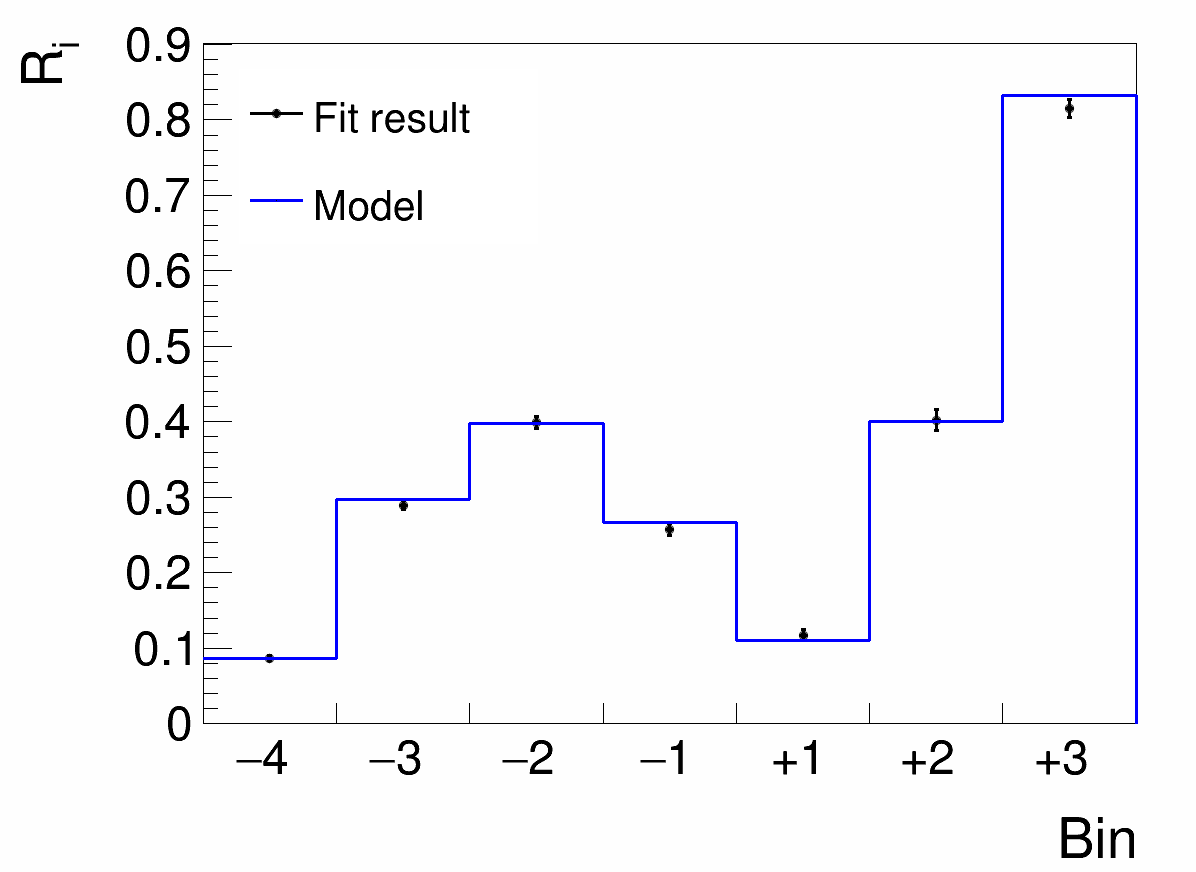

Info in <TCanvas::Print>: pdf file Ri_comparison_fit_model.pdf has been created


In [6]:
TCanvas c("c", "", 1200, 900);
TGraphErrors Fit(x.size(), x.data(), Values.data(), nullptr, Uncertainties.data());
TH1D Hist("h", "", 7, 0.0, 7.0);
for(std::size_t i = 0; i < 7; i++) {
    Hist.SetBinContent(i + 1, ModelPredictions[i]);
}
Fit.GetXaxis()->SetNdivisions(-007);
Fit.GetXaxis()->ChangeLabel(1, -1, -1, -1, -1, -1, "       #minus4");
Fit.GetXaxis()->ChangeLabel(2, -1, -1, -1, -1, -1, "       #minus3");
Fit.GetXaxis()->ChangeLabel(3, -1, -1, -1, -1, -1, "       #minus2");
Fit.GetXaxis()->ChangeLabel(4, -1, -1, -1, -1, -1, "       #minus1");
Fit.GetXaxis()->ChangeLabel(5, -1, -1, -1, -1, -1, "         +1");
Fit.GetXaxis()->ChangeLabel(6, -1, -1, -1, -1, -1, "         +2");
Fit.GetXaxis()->ChangeLabel(7, -1, -1, -1, -1, -1, "         +3");
Fit.GetXaxis()->ChangeLabel(8, -1, -1, -1, -1, -1, " ");
Fit.GetXaxis()->SetLimits(0.0, 7.0);
Fit.SetMinimum(0.0);
Fit.SetLineWidth(3);
Fit.SetLineColor(kBlack);
Fit.SetMarkerStyle(8);
Hist.SetLineWidth(3);
Hist.SetLineColor(kBlue);
Fit.SetTitle(";Bin;R_{i}");
Fit.Draw("AP E1");
Hist.Draw("HIST SAME");
TLegend Legend(0.2, 0.72, 0.45, 0.92);
Legend.AddEntry(&Fit, "Fit result");
Legend.AddEntry(&Hist, "Model");
Legend.Draw("SAME");
c.Draw();
c.SaveAs("Ri_comparison_fit_model.pdf");

In [7]:
c.Close();